# 01 – GANs: a tiny, real, from-scratch generative adversarial network

This notebook trains a REAL (small) GAN on a toy 2D distribution and actually runs every cell —
no fabricated output. It reuses the 5-step PyTorch training-loop pattern from
`09-pytorch/02-nn-module-and-training-loop` (forward → loss → `.backward()` → `optimizer.step()` →
`zero_grad()`) applied *twice per iteration* — once for the discriminator, once for the generator —
which is the only new mechanism a GAN adds on top of that pattern.

See `notes.md` for the full derivation of the min-max objective and mode-collapse failure mode.


In [1]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Tiny models on CPU: force single-threaded BLAS so PyTorch doesn't oversubscribe
# threads for matrices this small (thread-launch overhead would otherwise dominate
# runtime and make a "toy scale" run misleadingly slow).
torch.set_num_threads(1)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)


## 1. The toy 2D distribution

A ring of 8 Gaussian "modes" arranged on a circle — a standard toy benchmark for GAN mode collapse
because it is trivial to eyeball whether a generator has captured *all 8* modes or collapsed onto
just one or two. We only have *samples* from this distribution (via `sample_real`), never its
closed-form density — exactly the "unknown distribution, only examples" setting from `notes.md`'s
Problem section.


real sample mean: [-0.02279891  0.06202313]
real sample std:  [1.4356362 1.3915142]


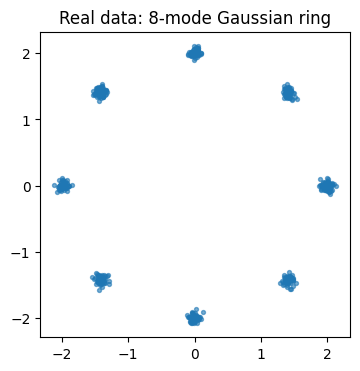

In [2]:
def sample_real(n):
    angles = np.random.choice(8, size=n) * (2 * np.pi / 8)
    radius = 2.0
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    noise = np.random.randn(n, 2) * 0.05
    return torch.tensor(centers + noise, dtype=torch.float32)

real_sample = sample_real(500)
print("real sample mean:", real_sample.mean(0).numpy())
print("real sample std: ", real_sample.std(0).numpy())

plt.figure(figsize=(4, 4))
plt.scatter(real_sample[:, 0], real_sample[:, 1], s=8, alpha=0.6)
plt.title("Real data: 8-mode Gaussian ring")
plt.gca().set_aspect("equal")
plt.show()


## 2. Generator and Discriminator — `nn.Module`, same pattern as `09-pytorch/02-nn-module-and-training-loop`

Both are small MLPs built exactly the way that topic's `MLP` class was: sub-modules assigned as
attributes in `__init__`, parameters discovered automatically via `.parameters()`, no tensor named
by hand anywhere in the training loop.

- **Generator** `G`: maps a random noise vector $z \in \mathbb{R}^2$ to a point in the same 2D
  space as the real data. Its job is to make `G(z)` indistinguishable from real samples.
- **Discriminator** `D`: maps a 2D point to a scalar probability in $(0, 1)$ — its estimate that the
  point came from the real distribution rather than from `G`.


In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim=2, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


Z_DIM = 2
G = Generator(z_dim=Z_DIM)
D = Discriminator()
print(G)
print(D)


Generator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 3. Before training: the generator is just noise

With random initial weights, `G(z)` has no relationship to the real ring — this is the baseline the
training loop below has to improve on.


fake (untrained) mean: [0.04246967 0.11687066]
fake (untrained) std:  [0.07247624 0.02706802]


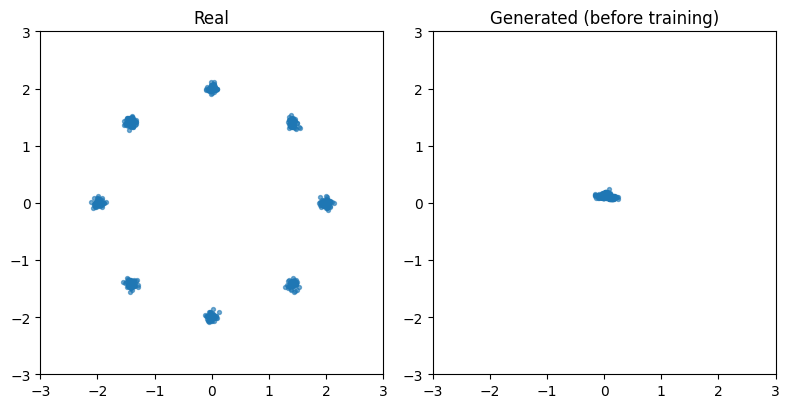

In [4]:
with torch.no_grad():
    z = torch.randn(500, Z_DIM)
    fake_before = G(z)

print("fake (untrained) mean:", fake_before.mean(0).numpy())
print("fake (untrained) std: ", fake_before.std(0).numpy())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, data, title in zip(
    axes, [real_sample, fake_before], ["Real", "Generated (before training)"]
):
    ax.scatter(data[:, 0], data[:, 1], s=8, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()


## 4. Training loop

Each iteration runs the 5-step `09-pytorch/02-nn-module-and-training-loop` pattern **twice**:

**Discriminator step** (forward → loss → backward → step → zero_grad), maximizing
$\log D(x) + \log(1 - D(G(z)))$ (implemented as minimizing the corresponding `BCELoss` against
real/fake labels):

1. `d_real = D(real_x)`, `d_fake = D(fake_x.detach())` — forward
2. `loss_d = BCE(d_real, 1) + BCE(d_fake, 0)` — loss
3. `loss_d.backward()` — backward
4. `opt_D.step()` — update D's parameters only
5. `opt_D.zero_grad()` — reset

**Generator step**, minimizing $\log(1 - D(G(z)))$ (equivalently maximizing $\log D(G(z))$, the
standard non-saturating trick used here for stronger early gradients — see `notes.md`):

1. `d_fake_for_g = D(G(z))` — forward (through G *and* D, but only G's parameters get updated)
2. `loss_g = BCE(d_fake_for_g, 1)` — loss (G wants D fooled into predicting "real")
3. `loss_g.backward()` — backward
4. `opt_G.step()` — update G's parameters only
5. `opt_G.zero_grad()` — reset

`fake_x.detach()` in the D step is essential: it stops gradients from flowing into G during the D
update, so each optimizer only ever touches its own model's parameters.


In [5]:
loss_fn = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=1e-3)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-3)

BATCH_SIZE = 128
N_EPOCHS = 2000

d_losses, g_losses = [], []
t0 = time.time()

for epoch in range(N_EPOCHS):
    # --- Discriminator step ---
    real_x = sample_real(BATCH_SIZE)
    z = torch.randn(BATCH_SIZE, Z_DIM)
    fake_x = G(z).detach()

    d_real = D(real_x)
    d_fake = D(fake_x)
    loss_d = loss_fn(d_real, torch.ones_like(d_real)) + loss_fn(d_fake, torch.zeros_like(d_fake))

    opt_D.zero_grad()
    loss_d.backward()
    opt_D.step()

    # --- Generator step ---
    z = torch.randn(BATCH_SIZE, Z_DIM)
    fake_x = G(z)
    d_fake_for_g = D(fake_x)
    loss_g = loss_fn(d_fake_for_g, torch.ones_like(d_fake_for_g))

    opt_G.zero_grad()
    loss_g.backward()
    opt_G.step()

    d_losses.append(loss_d.item())
    g_losses.append(loss_g.item())

    if epoch % 400 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:5d}  loss_D={loss_d.item():.4f}  loss_G={loss_g.item():.4f}")

print(f"training time: {time.time() - t0:.1f}s for {N_EPOCHS} epochs")


epoch     0  loss_D=1.3977  loss_G=0.7466


epoch   400  loss_D=0.7621  loss_G=1.6840


epoch   800  loss_D=0.6876  loss_G=2.2385


epoch  1200  loss_D=1.1411  loss_G=0.8300


epoch  1600  loss_D=1.1470  loss_G=0.8273


epoch  1999  loss_D=1.1151  loss_G=0.7722
training time: 3.5s for 2000 epochs


## 5. After training: real vs. generated

If training worked, the generated points should now spread across (approximately) all 8 modes of
the ring, not just match the mean/variance of a single Gaussian blob.


fake (trained) mean: [0.45498577 0.51894593]
fake (trained) std:  [1.7034883  0.89259565]
real            mean: [-0.02279891  0.06202313]
real            std:  [1.4356362 1.3915142]


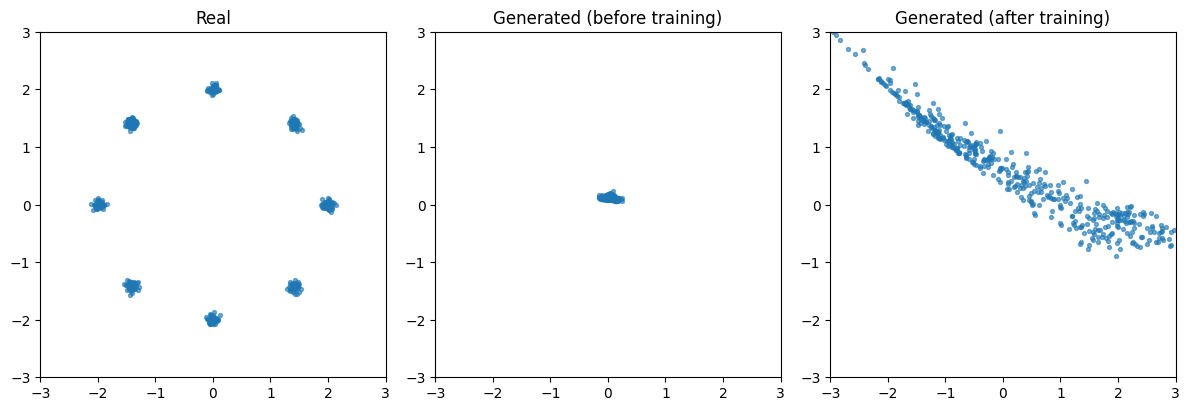

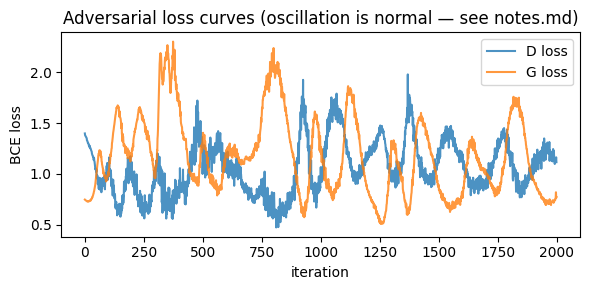

In [6]:
with torch.no_grad():
    z = torch.randn(500, Z_DIM)
    fake_after = G(z)

print("fake (trained) mean:", fake_after.mean(0).numpy())
print("fake (trained) std: ", fake_after.std(0).numpy())
print("real            mean:", real_sample.mean(0).numpy())
print("real            std: ", real_sample.std(0).numpy())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, data, title in zip(
    axes,
    [real_sample, fake_before, fake_after],
    ["Real", "Generated (before training)", "Generated (after training)"],
):
    ax.scatter(data[:, 0], data[:, 1], s=8, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(d_losses, label="D loss", alpha=0.8)
plt.plot(g_losses, label="G loss", alpha=0.8)
plt.xlabel("iteration")
plt.ylabel("BCE loss")
plt.title("Adversarial loss curves (oscillation is normal — see notes.md)")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Failure mode, demonstrated: mode collapse

`notes.md`'s Mathematical foundation section explains mode collapse as: if the generator finds a
single point (or narrow region) that reliably fools the *current* discriminator, gradient descent
on $\mathcal{L}_G$ gives it **no incentive to also cover the rest of the distribution** — a lower
loss is a lower loss, wherever it comes from. The classic way to trigger this at toy scale is an
imbalanced update schedule: give the generator many more update steps than the discriminator (here,
5 G-steps per D-step) with a generator learning rate high enough to sprint ahead. The discriminator
never gets the chance to reject whatever single point G currently favors before G has already
locked onto it.


In [7]:
torch.manual_seed(1)
np.random.seed(1)

G_collapse = Generator(z_dim=Z_DIM)
D_collapse = Discriminator()
opt_G_collapse = torch.optim.Adam(G_collapse.parameters(), lr=5e-3)   # G: fast
opt_D_collapse = torch.optim.Adam(D_collapse.parameters(), lr=1e-4)   # D: slow
G_STEPS_PER_D_STEP = 5
N_EPOCHS_COLLAPSE = 1500

t0 = time.time()
for epoch in range(N_EPOCHS_COLLAPSE):
    real_x = sample_real(BATCH_SIZE)
    z = torch.randn(BATCH_SIZE, Z_DIM)
    fake_x = G_collapse(z).detach()
    d_real = D_collapse(real_x)
    d_fake = D_collapse(fake_x)
    loss_d = loss_fn(d_real, torch.ones_like(d_real)) + loss_fn(d_fake, torch.zeros_like(d_fake))
    opt_D_collapse.zero_grad(); loss_d.backward(); opt_D_collapse.step()

    for _ in range(G_STEPS_PER_D_STEP):
        z = torch.randn(BATCH_SIZE, Z_DIM)
        fake_x = G_collapse(z)
        d_fake_for_g = D_collapse(fake_x)
        loss_g = loss_fn(d_fake_for_g, torch.ones_like(d_fake_for_g))
        opt_G_collapse.zero_grad(); loss_g.backward(); opt_G_collapse.step()

    if epoch % 300 == 0 or epoch == N_EPOCHS_COLLAPSE - 1:
        print(f"epoch {epoch:5d}  loss_D={loss_d.item():.4f}  loss_G={loss_g.item():.4f}")

print(f"training time: {time.time() - t0:.1f}s for {N_EPOCHS_COLLAPSE} epochs")

with torch.no_grad():
    z = torch.randn(500, Z_DIM)
    fake_collapsed = G_collapse(z)

print("collapsed generator std:", fake_collapsed.std(0).numpy(), "  (real std:", real_sample.std(0).numpy(), ")")


epoch     0  loss_D=1.4043  loss_G=0.6628


epoch   300  loss_D=1.4134  loss_G=0.6866


epoch   600  loss_D=1.3972  loss_G=0.6933


epoch   900  loss_D=1.3998  loss_G=0.7005


epoch  1200  loss_D=1.4011  loss_G=0.6898


epoch  1499  loss_D=1.3829  loss_G=0.7050
training time: 6.9s for 1500 epochs
collapsed generator std: [0.0037883  0.00137752]   (real std: [1.4356362 1.3915142] )


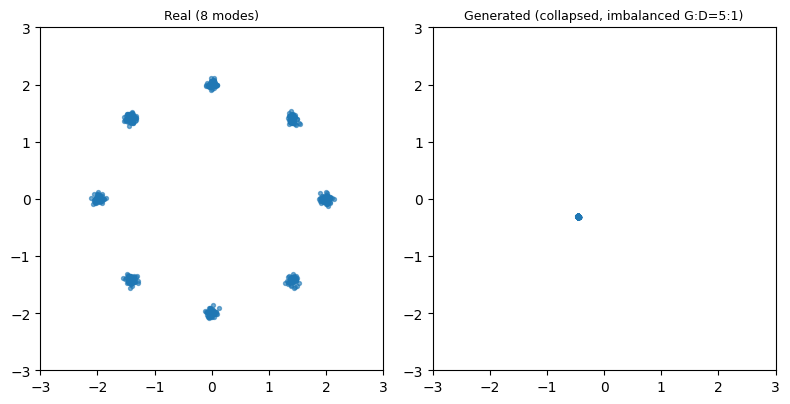

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, data, title in zip(
    axes, [real_sample, fake_collapsed], ["Real (8 modes)", "Generated (collapsed, imbalanced G:D=5:1)"]
):
    ax.scatter(data[:, 0], data[:, 1], s=8, alpha=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()


The collapsed run's generated standard deviation is roughly two orders of magnitude smaller than
the real distribution's — the generator is emitting essentially one point regardless of the input
noise `z`, exactly the mode-collapse signature: high sample "quality" (that one point may well fool
`D`) with near-zero diversity. Compare this to the properly-balanced run's `fake (trained) std`
above, which is on the same order as `real std`.

## 7. Failure mode, observed directly: training instability and oscillating loss

Look again at the loss-curve plot in section 5: unlike a supervised training loop's loss (which
should monotonically decrease, per `09-pytorch/02-nn-module-and-training-loop`'s Experiment), `loss_D`
and `loss_G` **oscillate** rather than settling. This is not a bug — it is the expected signature of
a two-player minimax game rather than a single descent problem: every time `D` improves and starts
rejecting `G`'s current outputs, `loss_G` rises; `G` then adapts and `loss_G` falls again, in turn
making `D`'s job harder, so `loss_D` rises. There is no single scalar loss whose steady decrease
certifies "the model is training correctly" the way there is for a classifier — see `notes.md`'s
Failure modes section for the full discussion of why (Nash-equilibrium framing) and for the
vanishing-gradient failure mode (D becoming too confident too early, driving `loss_G`'s gradient
toward zero).
